# Telecom Network & Customer Experience Analytics

In [3]:
# Import pandas library for data analysis
import pandas as pd

## Load Data

In [4]:
# Load customers data from CSV file
customers = pd.read_csv(r'C:\Users\Ravi Chandra\OneDrive\Documents\Pictures\pics\work\course task\task 2 files\customers.csv')

In [5]:
# Load network usage data
usage = pd.read_csv(r'C:\Users\Ravi Chandra\OneDrive\Documents\Pictures\pics\work\course task\task 2 files\network_usage.csv')

In [6]:
# Load network issues (complaints) data
issues = pd.read_csv(r"C:\Users\Ravi Chandra\OneDrive\Documents\Pictures\pics\work\course task\task 2 files\network_issues.csv")

In [7]:
# Load billing and payment data
billing = pd.read_csv(r"C:\Users\Ravi Chandra\OneDrive\Documents\Pictures\pics\work\course task\task 2 files\billing.csv")

In [8]:
# Display first 5 rows of each dataset to verify loading
print(customers.head(5))

   customer_id customer_type  age     city signup_date signup_month  \
0            1       Prepaid   34  kolkata  2020-10-21      October   
1            2      Postpaid   26  chennai  2022-12-05     December   
2            3      Postpaid   50   mumbai  2023-02-10     February   
3            4       Prepaid   37  chennai  2020-01-17      January   
4            5       Prepaid   30    delhi  2020-12-25     December   

   signup_year  
0         2020  
1         2022  
2         2023  
3         2020  
4         2020  


In [9]:
print(billing.head(5))

   bill_id  customer_id   bill_date bill_month  bill_year  bill_amount  \
0    30001          485  2024-03-20      March       2024          315   
1    30002            2  2024-06-08       June       2024          298   
2    30003          438  2024-03-12      March       2024          798   
3    30004          376  2023-04-28      April       2023         1058   
4    30005          402  2022-09-08  September       2022         1887   

  payment_status  
0        Delayed  
1         Failed  
2         Failed  
3         Failed  
4           Paid  


In [10]:
#Show all columns in one line
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

In [11]:
print(usage.head(5))

   usage_id  customer_id  usage_date usage_month  usage_year  data_used_gb  call_minutes network_type usage_category
0     10001          288  2023-09-20   September        2023          2.01            49           4G   Normal Usage
1     10002          167  2023-10-25     October        2023          2.50           134           5G   Normal Usage
2     10003          109  2024-04-29       April        2024          0.74           117           4G   Normal Usage
3     10004          494  2022-02-19    February        2022          7.42            59           4G     High Usage
4     10005           36  2023-05-17         May        2023          0.47           124           5G   Normal Usage


In [12]:
print(issues.head(5))

   issue_id  customer_id  issue_date issue_month  issue_year     issue_type  resolution_time_hrs resolved       city
0     20001           17  2023-10-22     October        2023      No Signal                    2      Yes  bangalore
1     20002          366  2022-09-16   September        2022  Slow Internet                   67      Yes     mumbai
2     20003          389  2023-06-26        June        2023      Call Drop                   15      Yes  bangalore
3     20004           26  2023-06-14        June        2023  Slow Internet                   21      Yes  bangalore
4     20005          213  2022-07-06        July        2022      No Signal                   59      Yes  hyderabad


In [13]:
# Group data by customer_id and count number of complaints
complaints = issues.groupby('customer_id').size().reset_index(name='total_complaints')

# Check result
print(complaints.head())

   customer_id  total_complaints
0            1                 6
1            2                 7
2            3                 3
3            4                 6
4            5                 8


In [14]:
df = customers.merge(complaints, on='customer_id', how='left')
df = df.merge(billing[['customer_id', 'payment_status']], on='customer_id', how='left')
df['total_complaints'] = df['total_complaints'].fillna(0)

print(df.head())

   customer_id customer_type  age     city signup_date signup_month  signup_year  total_complaints payment_status
0            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0           Paid
1            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0           Paid
2            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0         Failed
3            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0           Paid
4            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0        Delayed


In [15]:
# Merge customers with complaints data
df = customers.merge(complaints, on='customer_id', how='left')

# Merge billing to get payment status
df = df.merge(billing[['customer_id', 'payment_status']], on='customer_id', how='left')

# Fill missing complaints with 0
df['total_complaints'] = df['total_complaints'].fillna(0)

# Display data
print(df.head())

   customer_id customer_type  age     city signup_date signup_month  signup_year  total_complaints payment_status
0            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0           Paid
1            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0           Paid
2            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0         Failed
3            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0           Paid
4            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0        Delayed


In [15]:
# Merge customers with complaints data
df = customers.merge(complaints, on='customer_id', how='left')

# Merge billing to get payment status
df = df.merge(billing[['customer_id', 'payment_status']], on='customer_id', how='left')

# Fill missing complaints with 0
df['total_complaints'] = df['total_complaints'].fillna(0)

# Display data
print(df.head())

   customer_id customer_type  age     city signup_date signup_month  signup_year  total_complaints payment_status
0            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0           Paid
1            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0           Paid
2            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0         Failed
3            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0           Paid
4            1       Prepaid   34  kolkata  2020-10-21      October         2020               6.0        Delayed


In [16]:
# Count complaints per customer
complaints = issues.groupby('customer_id').size().reset_index(name='total_complaints')

In [17]:
# Keep only one payment status per customer to avoid duplicates
billing_unique = billing.groupby('customer_id')['payment_status'].last().reset_index()

In [19]:
# Merge all data into one dataframe
df = customers.merge(complaints, on='customer_id', how='left')
df = df.merge(billing_unique, on='customer_id', how='left')

# Fill missing values
df['total_complaints'] = df['total_complaints'].fillna(0)

print(df.head(10))

   customer_id customer_type  age       city signup_date signup_month  signup_year  total_complaints payment_status
0            1       Prepaid   34    kolkata  2020-10-21      October         2020               6.0           Paid
1            2      Postpaid   26    chennai  2022-12-05     December         2022               7.0        Delayed
2            3      Postpaid   50     mumbai  2023-02-10     February         2023               3.0           Paid
3            4       Prepaid   37    chennai  2020-01-17      January         2020               6.0           Paid
4            5       Prepaid   30      delhi  2020-12-25     December         2020               8.0        Delayed
5            6       Prepaid   45  bangalore  2022-05-15          May         2022               7.0           Paid
6            7       Prepaid   46  bangalore  2021-11-30     November         2021              11.0         Failed
7            8      Postpaid   30     mumbai  2021-03-23        March   

In [20]:
# Function to assign risk category based on complaints and payment status
def risk_score(row):
    if row['total_complaints'] > 5 and row['payment_status'] == 'Delayed':
        return 'High Risk'
    elif row['total_complaints'] > 3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

# Apply function to create new column
df['risk_category'] = df.apply(risk_score, axis=1)

# Display result
print(df[['customer_id', 'total_complaints', 'payment_status', 'risk_category']].head())

   customer_id  total_complaints payment_status risk_category
0            1               6.0           Paid   Medium Risk
1            2               7.0        Delayed     High Risk
2            3               3.0           Paid      Low Risk
3            4               6.0           Paid   Medium Risk
4            5               8.0        Delayed     High Risk


In [21]:
# Create heavy usage flag using lambda function
usage['heavy_usage_flag'] = usage['data_used_gb'].apply(
    lambda x: 'Heavy User' if x > 6 else 'Normal User'
)

# Display result
print(usage[['data_used_gb', 'heavy_usage_flag']].head())

   data_used_gb heavy_usage_flag
0          2.01      Normal User
1          2.50      Normal User
2          0.74      Normal User
3          7.42       Heavy User
4          0.47      Normal User


In [22]:
# Count number of customers in each risk category
print(df['risk_category'].value_counts())

risk_category
Medium Risk    368
Low Risk        88
High Risk       44
Name: count, dtype: int64


In [24]:
# Count number of customers in each risk category and convert result into a table format
df['risk_category'].value_counts().reset_index(name='count')

,risk_category,count
0,Medium Risk,368
1,Low Risk,88
2,High Risk,44


In [27]:
# Import plotting library
import matplotlib.pyplot as plt

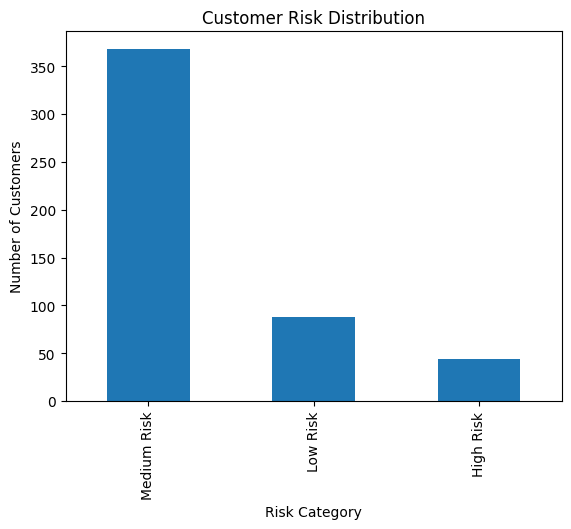

In [28]:
# Visualize risk category distribution using bar chart
df['risk_category'].value_counts().plot(kind='bar')

plt.title("Customer Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

plt.show()